In [7]:
from google.colab import drive
drive.mount('/content/drive')

!git clone https://github.com/falkodz/TER.git /content/TER

Mounted at /content/drive
Cloning into '/content/TER'...
remote: Enumerating objects: 38, done.
remote: Counting objects: 100% (38/38), done.
remote: Compressing objects: 100% (30/30), done.
remote: Total 38 (delta 14), reused 30 (delta 6), pack-reused 0 (from 0)
Receiving objects: 100% (38/38), 1.46 MiB | 16.10 MiB/s, done.
Resolving deltas: 100% (14/14), done.


In [8]:
import os, shutil
os.makedirs('/content/TER/data', exist_ok=True)
shutil.copy('/content/drive/MyDrive/Colab Notebooks/ChatGPT_final.csv',
            '/content/TER/data/ChatGPT_final.csv')
print("Done ✓")

Done ✓


In [5]:
!pip install ruptures wordcloud -q

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import ruptures as rpt
from wordcloud import WordCloud
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('/content/TER/data/ChatGPT_final.csv',
                 usecols=['Date', 'cleaned_tweet', 'sentiment', 'compound_score'],
                 low_memory=False)

df['Date'] = pd.to_datetime(df['Date'], utc=True, errors='coerce')
df = df.dropna(subset=['Date', 'sentiment'])
df['day'] = df['Date'].dt.date

print(f"Shape: {df.shape}")
print(f"Date range: {df['Date'].min()} → {df['Date'].max()}")

Shape: (476164, 5)
Date range: 2022-11-30 18:13:41+00:00 → 2023-04-08 03:33:13+00:00


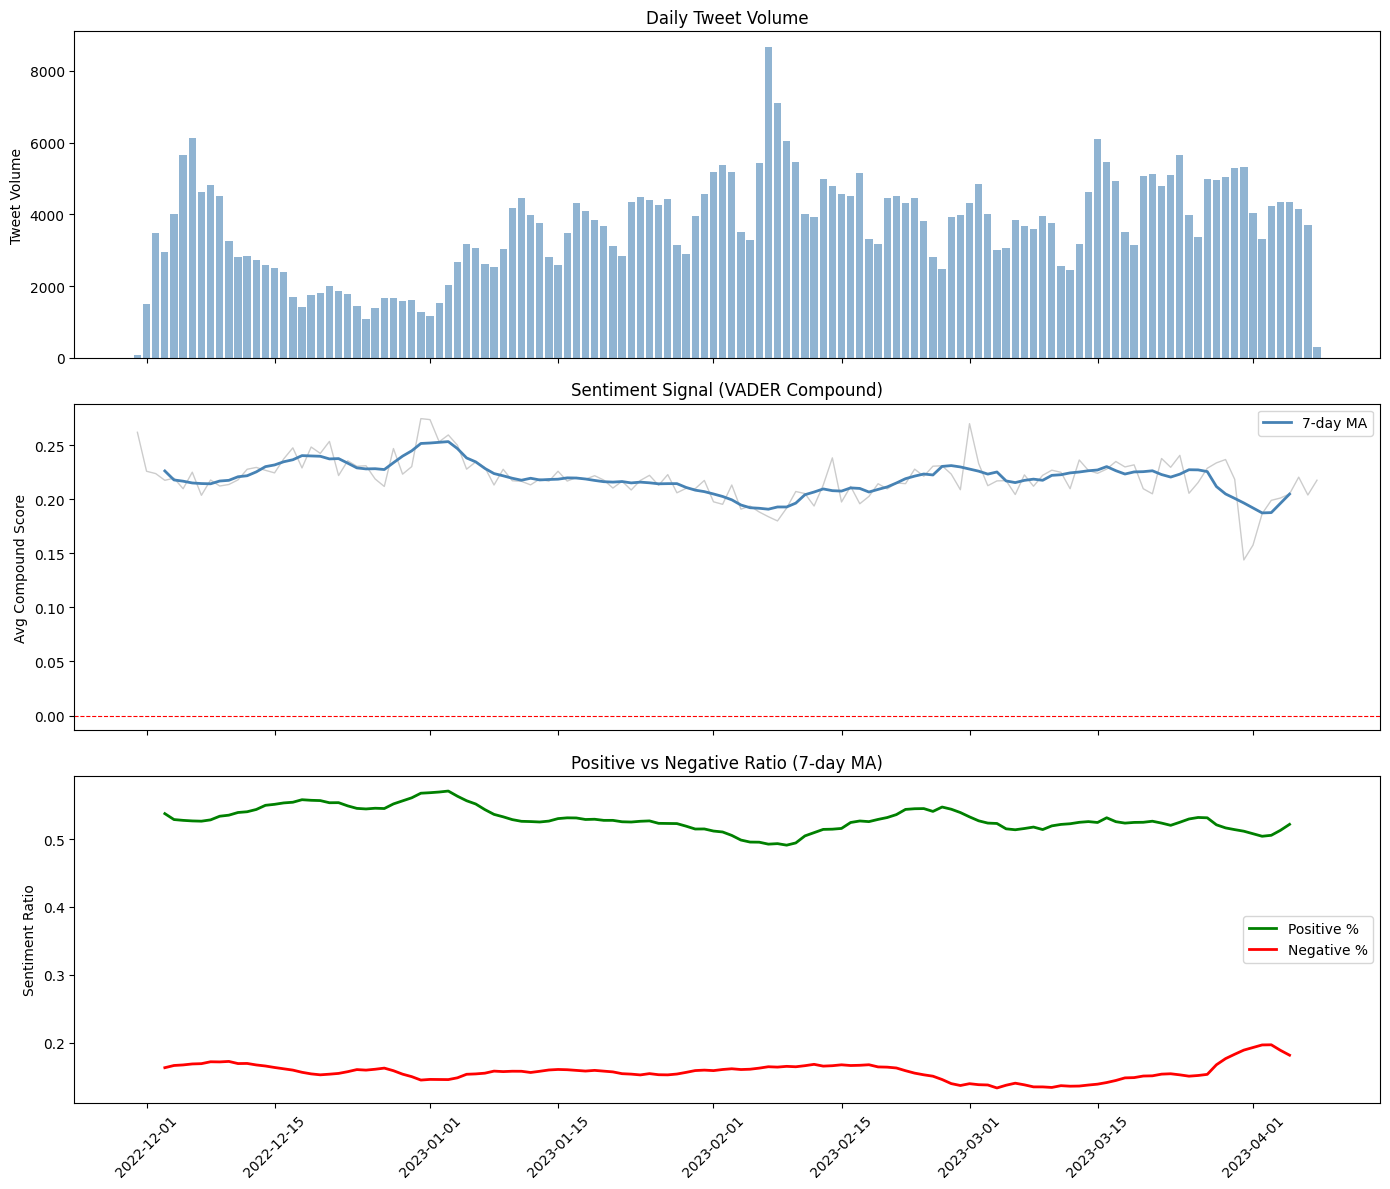

In [12]:
fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

# Plot 1 — Volume de tweets
axes[0].bar(daily['day'], daily['tweet_count'], color='steelblue', alpha=0.6, width=0.8)
axes[0].set_ylabel('Tweet Volume')
axes[0].set_title('Daily Tweet Volume', fontsize=12)

# Plot 2 — Compound score moyen + moving average
axes[1].plot(daily['day'], daily['avg_compound'], color='gray', alpha=0.4, linewidth=1)
axes[1].plot(daily['day'], daily['ma7_compound'], color='steelblue', linewidth=2, label='7-day MA')
axes[1].axhline(0, color='red', linestyle='--', linewidth=0.8)
axes[1].set_ylabel('Avg Compound Score')
axes[1].set_title('Sentiment Signal (VADER Compound)', fontsize=12)
axes[1].legend()

# Plot 3 — % positif vs négatif
axes[2].plot(daily['day'], daily['ma7_positive'], color='green', linewidth=2, label='Positive %')
axes[2].plot(daily['day'], daily['pct_negative'].rolling(7, center=True).mean(),
             color='red', linewidth=2, label='Negative %')
axes[2].set_ylabel('Sentiment Ratio')
axes[2].set_title('Positive vs Negative Ratio (7-day MA)', fontsize=12)
axes[2].legend()

plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('/content/TER/figures/06_sentiment_timeseries.png', dpi=150)
plt.show()

In [14]:
# Augmenter la pénalité pour moins de change points
model = rpt.Pelt(model="rbf").fit(signal)
breakpoints = model.predict(pen=3)

print(f"Change points détectés : {len(breakpoints)-1}")

valid_days = daily['day'].dropna().reset_index(drop=True)
cp_dates = [valid_days.iloc[bp-1] for bp in breakpoints[:-1]]
print(f"\nDates des change points :")
for d in cp_dates:
    print(f"  → {d.strftime('%Y-%m-%d')}")

Change points détectés : 6

Dates des change points :
  → 2022-12-09
  → 2023-01-03
  → 2023-01-28
  → 2023-02-07
  → 2023-02-17
  → 2023-03-24


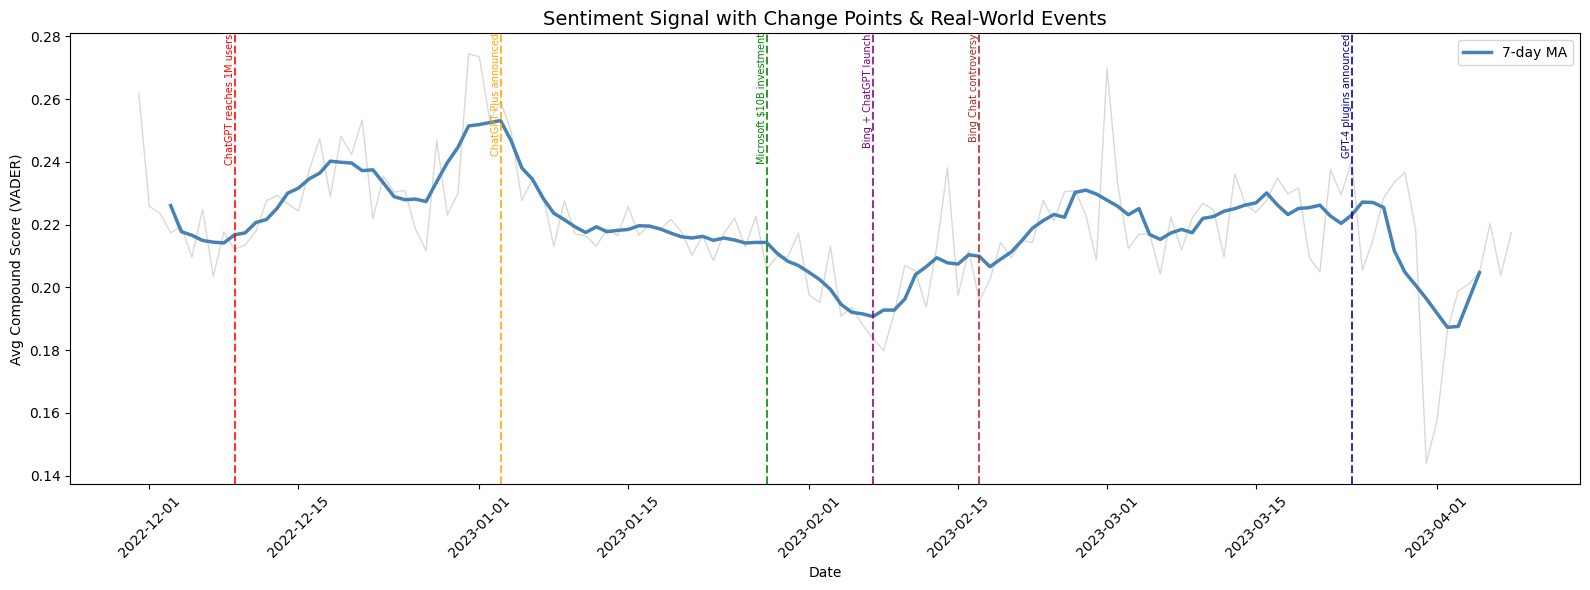

In [15]:
# Événements réels ChatGPT
events = {
    '2022-12-09': 'ChatGPT reaches 1M users',
    '2023-01-03': 'ChatGPT Plus announced',
    '2023-01-28': 'Microsoft $10B investment',
    '2023-02-07': 'Bing + ChatGPT launch',
    '2023-02-17': 'Bing Chat controversy',
    '2023-03-24': 'GPT-4 plugins announced'
}

fig, ax = plt.subplots(figsize=(16, 6))

# Signal + moving average
ax.plot(daily['day'], daily['avg_compound'], color='gray', alpha=0.3, linewidth=1)
ax.plot(daily['day'], daily['ma7_compound'], color='steelblue', linewidth=2.5, label='7-day MA')

# Change points + annotations
colors = ['red', 'orange', 'green', 'purple', 'brown', 'darkblue']
for i, (date, label) in enumerate(events.items()):
    ax.axvline(pd.Timestamp(date), color=colors[i], linestyle='--', linewidth=1.5, alpha=0.8)
    ax.text(pd.Timestamp(date), ax.get_ylim()[1] if ax.get_ylim()[1] > 0 else 0.28,
            label, rotation=90, fontsize=7, color=colors[i],
            verticalalignment='top', horizontalalignment='right')

ax.set_title('Sentiment Signal with Change Points & Real-World Events', fontsize=14)
ax.set_ylabel('Avg Compound Score (VADER)')
ax.set_xlabel('Date')
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('/content/TER/figures/07_changepoints_events.png', dpi=150)
plt.show()

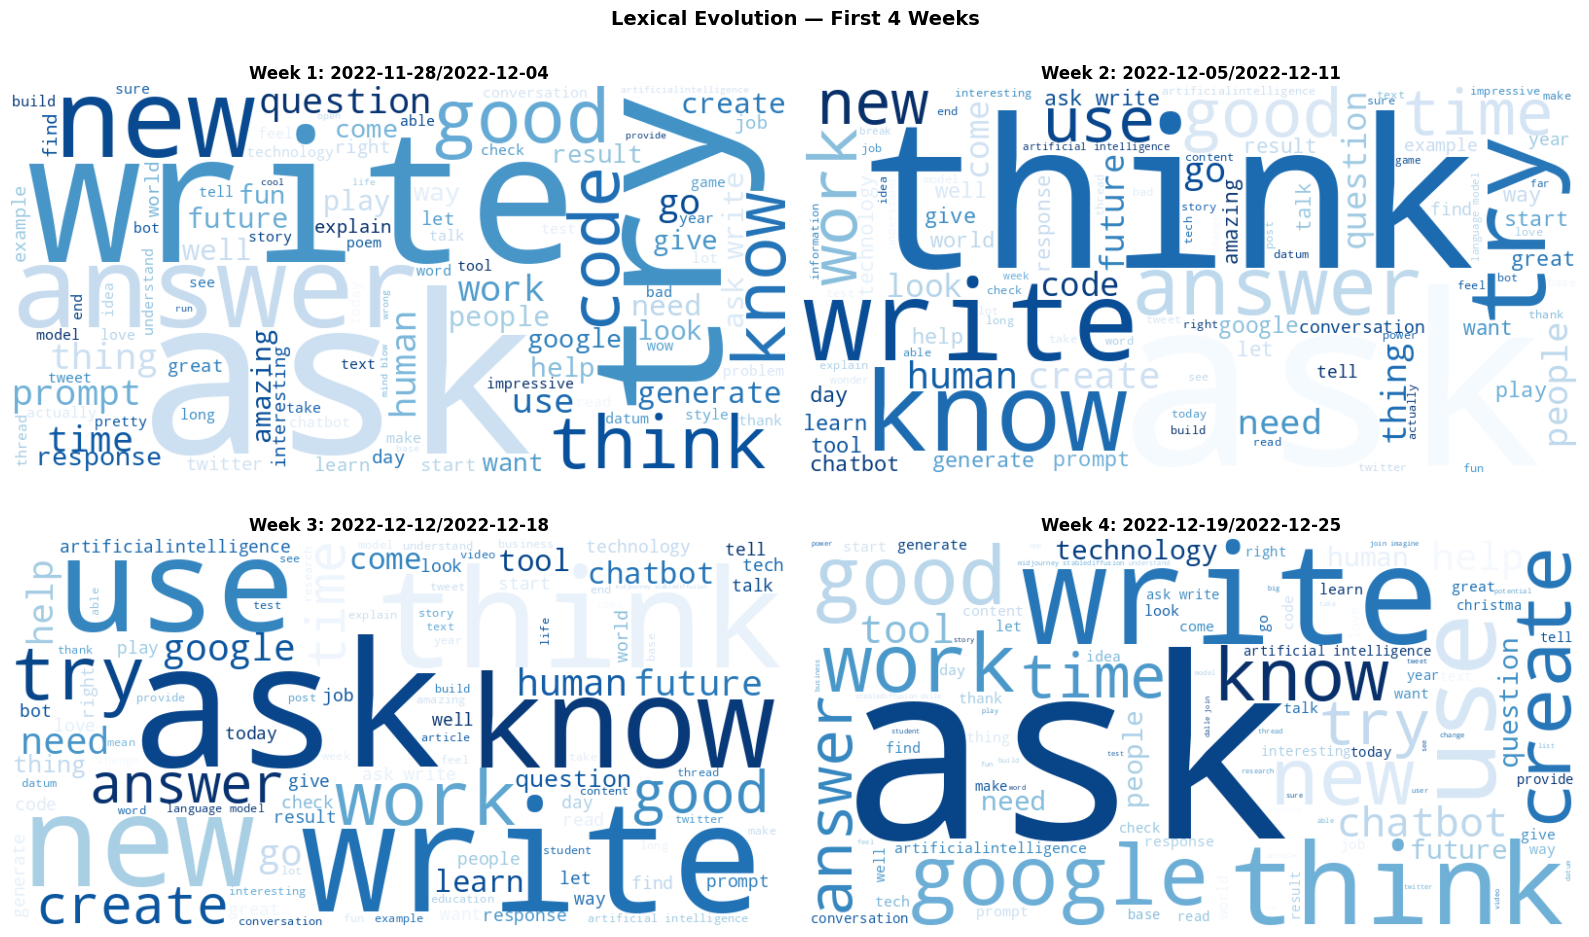

In [16]:
df['week'] = df['Date'].dt.to_period('W')
weeks = sorted(df['week'].unique())[:4]  # 4 premières semaines

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for i, week in enumerate(weeks):
    week_df = df[df['week'] == week]
    text = ' '.join(week_df['cleaned_tweet'].dropna().tolist())

    wc = WordCloud(width=800, height=400, background_color='white',
                   max_words=100, colormap='Blues').generate(text)

    axes[i].imshow(wc, interpolation='bilinear')
    axes[i].axis('off')
    axes[i].set_title(f'Week {i+1}: {str(week)}', fontsize=12, fontweight='bold')

plt.suptitle('Lexical Evolution — First 4 Weeks', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/TER/figures/08_weekly_wordclouds.png', dpi=150)
plt.show()

In [17]:
import subprocess
from getpass import getpass

subprocess.run(['git', 'add', '.'], cwd='/content/TER')
subprocess.run(['git', 'commit', '-m', 'Add temporal analysis: sentiment signal, change points, word clouds'], cwd='/content/TER')

token = getpass("Token GitHub : ")
result = subprocess.run(
    ['git', 'push', f'https://{token}@github.com/falkodz/TER.git', 'main'],
    cwd='/content/TER', capture_output=True, text=True
)
print(result.stdout)
print(result.stderr)

Token GitHub : ··········

Everything up-to-date

